In [9]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = " " * 4 * level
    print(indent + os.path.basename(root) + "/")

input/
    datasets/
        samuelcortinhas/
            cats-and-dogs-image-classification/
                test/
                    dogs/
                    cats/
                train/
                    dogs/
                    cats/


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [13]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [15]:
import os

DATASET_PATH = "/kaggle/input/datasets"

print(os.listdir(DATASET_PATH))

['samuelcortinhas']


In [16]:
import os

DATASET_PATH = "/kaggle/input/datasets/samuelcortinhas"

print(os.listdir(DATASET_PATH))

['cats-and-dogs-image-classification']


In [17]:
import os

DATASET_PATH = "/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification"

print(os.listdir(DATASET_PATH))

['test', 'train']


In [26]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Settings loaded successfully!")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Seed:", SEED)

Settings loaded successfully!
Image size: (224, 224)
Batch size: 32
Seed: 42


In [28]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 557 files belonging to 2 classes.
Using 446 files for training.
Found 557 files belonging to 2 classes.
Using 111 files for validation.
Found 140 files belonging to 2 classes.
Classes: ['cats', 'dogs']


In [29]:
class_names = train_ds.class_names

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['cats', 'dogs']
Number of classes: 2


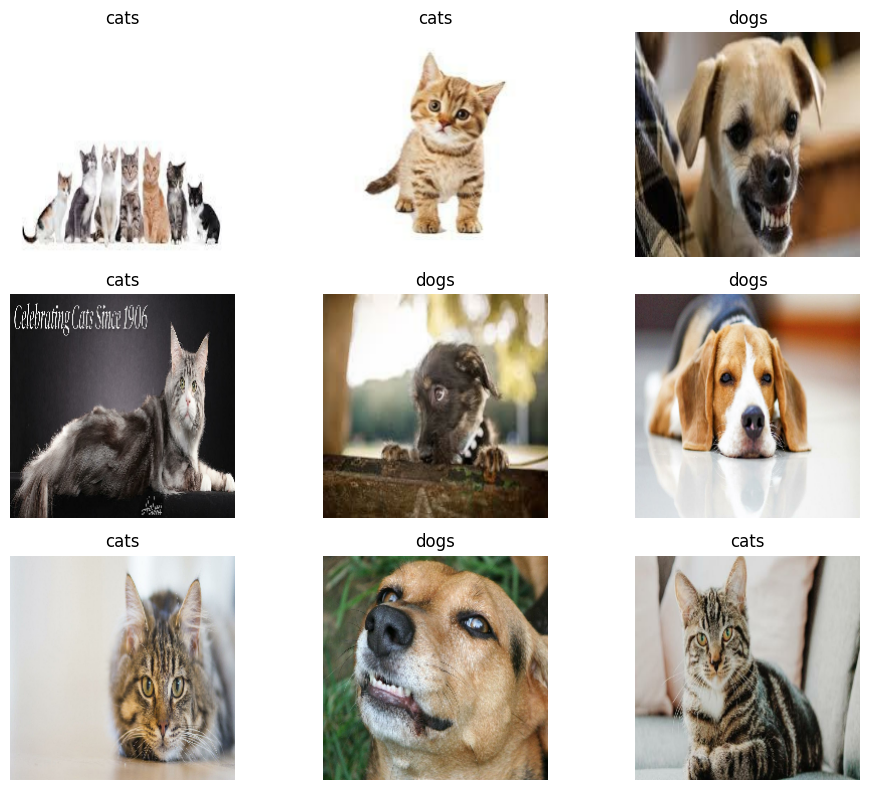

In [30]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset preparation completed successfully!")

Dataset preparation completed successfully!


In [2]:
from tensorflow.keras.applications import ResNet50

print("ResNet50 imported successfully!")

ResNet50 imported successfully!


In [3]:
WEIGHTS_PATH = r"C:\Users\santh\Downloads\resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5"

base_model = ResNet50(
    weights=WEIGHTS_PATH,
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet50 loaded successfully!")

ResNet50 loaded successfully!


In [4]:
# Freeze all ResNet50 layers
base_model.trainable = False

print("ResNet50 frozen successfully!")
print("Trainable:", base_model.trainable)

ResNet50 frozen successfully!
Trainable: False


In [7]:
import os
import tensorflow as tf

print("Required libraries loaded successfully!")

Required libraries loaded successfully!


In [10]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

DATASET_PATH = r"C:\path\to\your\dataset"

print("Dataset settings loaded!")

Dataset settings loaded!


In [13]:
import os

print("Searching for image folders...")

search_path = r"C:\Users\santh\Downloads"

found = []

for root, dirs, files in os.walk(search_path):

    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    if len(image_files) > 5:
        found.append((root, len(image_files)))

print("\nPossible dataset folders:\n")

for path, count in found[:30]:
    print(count, "images ->", path)

Searching for image folders...

Possible dataset folders:

27 images -> C:\Users\santh\Downloads
12 images -> C:\Users\santh\Downloads\24ADI003L-24BAD408\24ADI003L-24BAD408\EX01\output
17 images -> C:\Users\santh\Downloads\24ADI003L-24BAD408\24ADI003L-24BAD408\EX02\output
37 images -> C:\Users\santh\Downloads\24ADI003L-24BAD408\24ADI003L-24BAD408\EX03\output
30 images -> C:\Users\santh\Downloads\24ADI003L-24BAD408\24ADI003L-24BAD408\EX04\output
27 images -> C:\Users\santh\Downloads\24ADI003L-24BAD408\24ADI003L-24BAD408\EX05\output
12 images -> C:\Users\santh\Downloads\AI&A
69 images -> C:\Users\santh\Downloads\ilovepdf_pages-to-jpg


In [20]:
import os

DATASET_PATH = r"C:\New folder"

print("Dataset contents:")
print(os.listdir(DATASET_PATH))

Dataset contents:
['test', 'train']


In [21]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

TRAIN_PATH = os.path.join(DATASET_PATH, "train")

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Training and validation datasets loaded successfully!")

Found 557 files belonging to 2 classes.
Using 446 files for training.
Found 557 files belonging to 2 classes.
Using 111 files for validation.
Training and validation datasets loaded successfully!


In [22]:
class_names = train_ds.class_names

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['cats', 'dogs']
Number of classes: 2


In [23]:
TEST_PATH = os.path.join(DATASET_PATH, "test")

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test dataset loaded successfully!")

Found 140 files belonging to 2 classes.
Test dataset loaded successfully!


In [24]:
from tensorflow.keras.applications.resnet50 import preprocess_input

# Apply ResNet50 preprocessing
train_ds = train_ds.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Improve performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("ResNet50 preprocessing completed successfully!")

ResNet50 preprocessing completed successfully!


In [25]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    
    # Data augmentation
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    
    # Pre-trained ResNet50
    base_model,
    
    # Convert feature maps into a feature vector
    tf.keras.layers.GlobalAveragePooling2D(),
    
    # New trainable classification layer
    tf.keras.layers.Dense(128, activation="relu"),
    
    # Reduce overfitting
    tf.keras.layers.Dropout(0.5),
    
    # Final classification layer
    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

print("Transfer learning model created successfully!")

Transfer learning model created successfully!


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [28]:
# Build the model by giving it the input shape
model.build(input_shape=(None, 224, 224, 3))

print("Model built successfully!")
print("Total parameters:", model.count_params())

print("\nTrainable layers:")

for layer in model.layers:
    print(layer.name, "->", layer.trainable)

Model built successfully!
Total parameters: 23850242

Trainable layers:
random_flip -> True
random_rotation -> True
random_zoom -> True
resnet50 -> False
global_average_pooling2d -> True
dense -> True
dropout -> True
dense_1 -> True


In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    
    loss="sparse_categorical_crossentropy",
    
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [30]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6637 - loss: 0.6723 - val_accuracy: 0.8829 - val_loss: 0.3678
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8386 - loss: 0.3547 - val_accuracy: 0.9279 - val_loss: 0.2283
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8946 - loss: 0.2662 - val_accuracy: 0.9279 - val_loss: 0.1717
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9058 - loss: 0.2272 - val_accuracy: 0.9459 - val_loss: 0.1480
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9417 - loss: 0.1506 - val_accuracy: 0.9550 - val_loss: 0.1345
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9552 - loss: 0.1264 - val_accuracy: 0.9640 - val_loss: 0.1270
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9417 - loss: 0.1357 - val_accuracy: 0.9640 - val_loss: 0.1165
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9731 - loss: 0.1145 - val_accuracy: 0.9640 - val_loss:

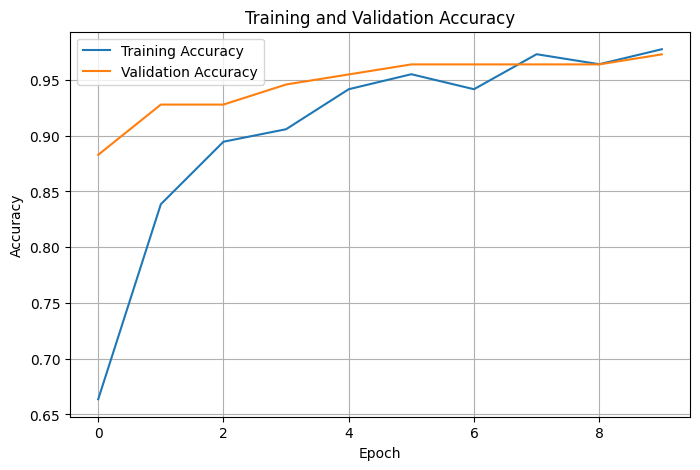

In [32]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

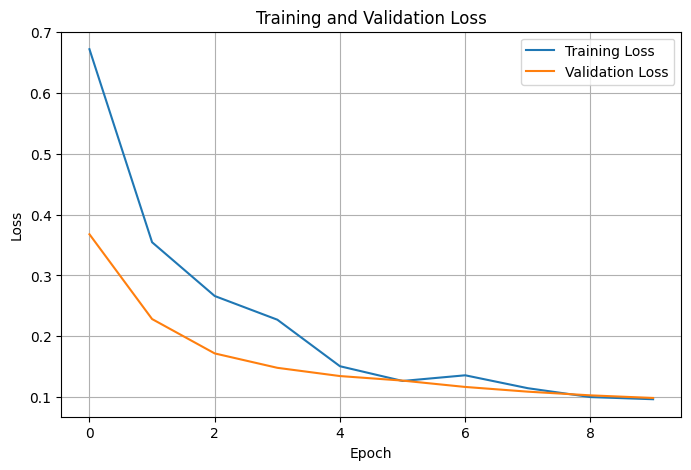

In [33]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [34]:
# Evaluate the trained model on the test dataset

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("\n===== TEST RESULTS =====")
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)
print("Test Accuracy % :", round(test_accuracy * 100, 2), "%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9429 - loss: 0.1287

===== TEST RESULTS =====
Test Loss     : 0.1287086457014084
Test Accuracy : 0.9428571462631226
Test Accuracy % : 94.29 %


In [35]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")
print("Number of test images:", len(y_true))

Predictions generated successfully!
Number of test images: 140


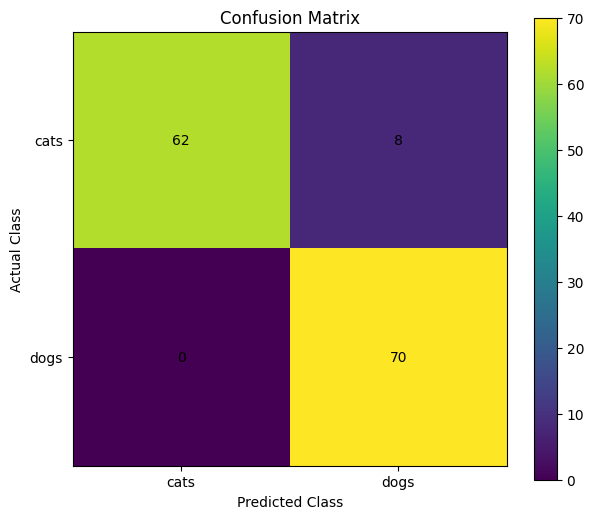

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
plt.figure(figsize=(7, 6))

plt.imshow(cm)

# Add numbers inside the matrix
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

# Add class labels
plt.xticks(
    range(len(class_names)),
    class_names
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [38]:
from sklearn.metrics import classification_report

# Calculate Precision, Recall and F1-score
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("===== CLASSIFICATION REPORT =====")
print(report)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        cats       1.00      0.89      0.94        70
        dogs       0.90      1.00      0.95        70

    accuracy                           0.94       140
   macro avg       0.95      0.94      0.94       140
weighted avg       0.95      0.94      0.94       140



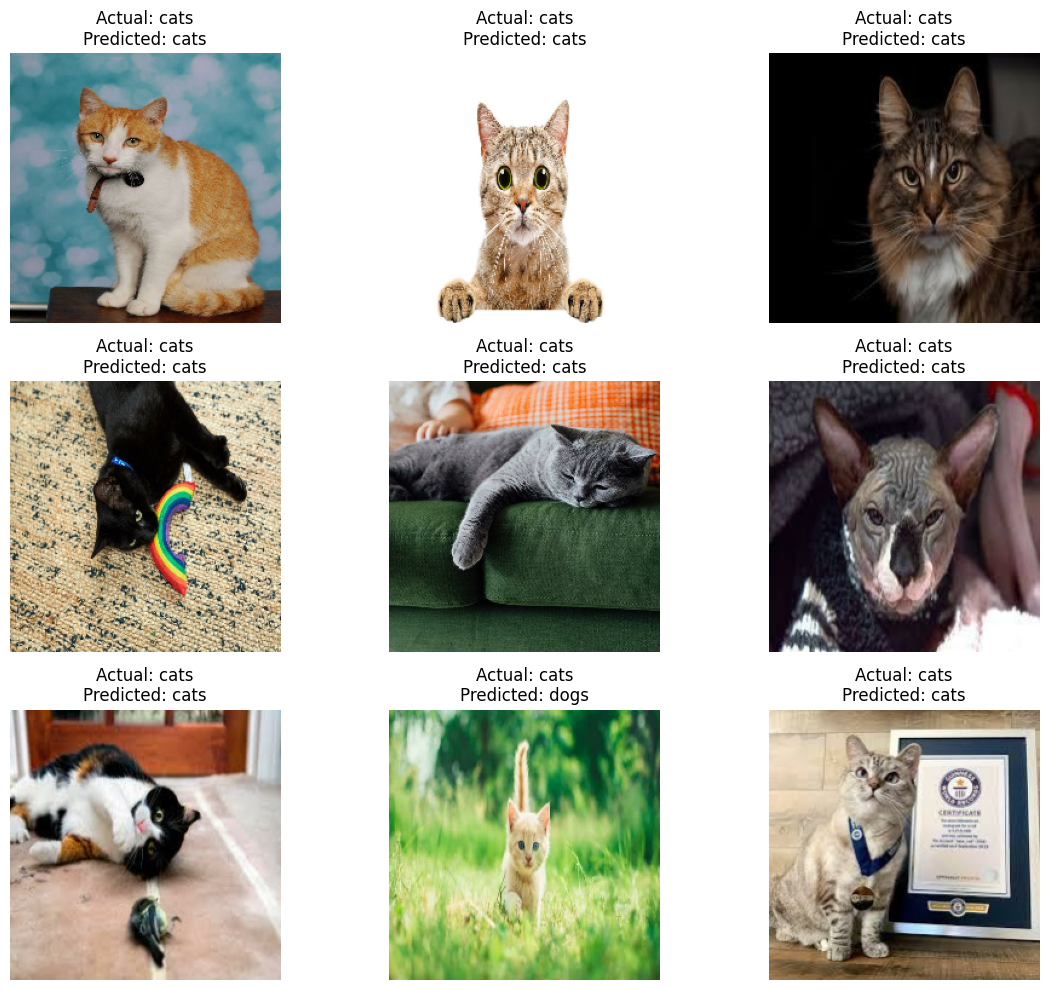

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the test dataset
for images, labels in test_ds.take(1):

    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12, 10))

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        # Convert the image back approximately for display
        image = images[i].numpy()

        image = image + [103.939, 116.779, 123.68]
        image = image[..., ::-1]
        image = np.clip(image / 255.0, 0, 1)

        plt.imshow(image)

        actual = class_names[int(labels[i])]
        predicted = class_names[int(predicted_classes[i])]

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [40]:
# Take one image from the test dataset
for images, labels in test_ds.take(1):
    sample_image = images[0]
    actual_label = int(labels[0].numpy())
    break

# Predict the image
prediction = model.predict(
    tf.expand_dims(sample_image, axis=0),
    verbose=0
)

# Find the class with the highest probability
predicted_class = int(np.argmax(prediction[0]))

# Get confidence
confidence = float(prediction[0][predicted_class])

print("===== SINGLE IMAGE PREDICTION =====")
print("Actual Class    :", class_names[actual_label])
print("Predicted Class :", class_names[predicted_class])
print("Confidence      :", round(confidence * 100, 2), "%")

===== SINGLE IMAGE PREDICTION =====
Actual Class    : cats
Predicted Class : cats
Confidence      : 99.74 %


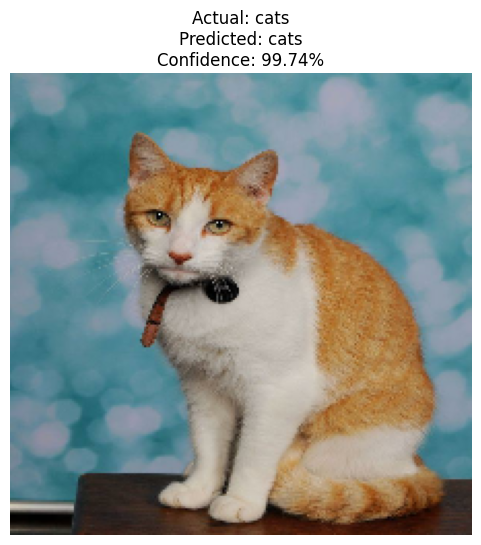

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Display the selected test image
plt.figure(figsize=(6, 6))

# Convert image for display
image = sample_image.numpy()
image = image + [103.939, 116.779, 123.68]
image = image[..., ::-1]
image = np.clip(image / 255.0, 0, 1)

plt.imshow(image)

plt.title(
    f"Actual: {class_names[actual_label]}\n"
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()

In [42]:
# Install Hugging Face Transformers
!pip install -q transformers


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
!pip install torch torchvision

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/122.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/122.0 MB 11.2 MB/s eta 0:00:11
    --------------------------------------- 2.9/122.0 MB 9.3 MB/s eta 0:00:13
   - -------------------------------------- 4.5/122.0 MB 8.6 MB/s eta 0:00:14
   -- ------------------------------------- 6.8/122.0 MB 9.8 MB/s eta 0:00:12
   -- ------------------------------------- 7.9/122.0 MB 9.5 MB/s eta 0:00:12
   --- ------------------------------------ 10.0/122.0 MB 8.6 MB/s eta 0:00:13
   --- ------------------------------------ 11.3/122.0 MB 8.2 MB/s eta 0:00:14
   ---- ----------------------------------- 12.3/122.0 MB 7.8 MB/s eta 0:00:15
   ---- ----------------------------------- 14.4/122.0 MB 8.1 MB/s eta 0:00:14
   ----- ---------------------------------- 17.6/122.0 MB 8.9 MB/s eta 0:00:12
   ------ --------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import torch

print("PyTorch version:", torch.__version__)
print("PyTorch installed successfully!")

PyTorch version: 2.13.0+cpu
PyTorch installed successfully!


In [1]:
import torch

print("PyTorch:", torch.__version__)

from transformers import pipeline

hf_classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224",
    device=-1
)

print("Hugging Face ViT model loaded successfully!")

PyTorch: 2.13.0+cpu


c:\Users\santh\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 2847.75it/s]


Hugging Face ViT model loaded successfully!


Found 140 files belonging to 2 classes.


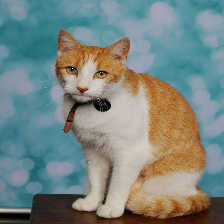

Actual class: cats


In [5]:
import tensorflow as tf
from PIL import Image

# Dataset settings
DATASET_PATH = r"C:\New folder"
TEST_PATH = r"C:\New folder\test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Class names
class_names = ["cats", "dogs"]

# Load the original test dataset
original_test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get one test image
for images, labels in original_test_ds.take(1):
    hf_image = images[0]
    actual_label = int(labels[0].numpy())
    break

# Convert TensorFlow image to PIL image
hf_image = hf_image.numpy().astype("uint8")
hf_image = Image.fromarray(hf_image)

# Display the image
display(hf_image)

print("Actual class:", class_names[actual_label])

In [6]:
# Get Hugging Face ViT predictions
hf_results = hf_classifier(hf_image)

print("===== HUGGING FACE ViT PREDICTION =====")

for result in hf_results[:5]:
    print(
        result["label"],
        "->",
        round(result["score"] * 100, 2),
        "%"
    )

===== HUGGING FACE ViT PREDICTION =====
tiger cat -> 36.25 %
Egyptian cat -> 27.54 %
tabby, tabby cat -> 12.65 %
bow tie, bow-tie, bowtie -> 2.53 %
lynx, catamount -> 0.89 %


In [8]:
print("Checking variables...")

print("model exists:", "model" in globals())
print("base_model exists:", "base_model" in globals())
print("sample_image exists:", "sample_image" in globals())
print("hf_results exists:", "hf_results" in globals())

Checking variables...
model exists: False
base_model exists: False
sample_image exists: False
hf_results exists: True


In [9]:
import tensorflow as tf

# Recreate the ResNet50 base model using your local weights
WEIGHTS_PATH = r"C:\Users\santh\Downloads\resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5"

from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights=WEIGHTS_PATH,
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ResNet50
base_model.trainable = False

# Create the classifier again
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(2, activation="softmax")
])

model.build(input_shape=(None, 224, 224, 3))

print("ResNet50 model recreated successfully!")

ResNet50 model recreated successfully!


In [10]:
# Compile the ResNet50 transfer learning model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
import tensorflow as tf

# Dataset paths
TRAIN_PATH = r"C:\New folder\train"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Get class names
class_names = train_ds.class_names

print("Training and validation datasets loaded successfully!")
print("Classes:", class_names)

Found 557 files belonging to 2 classes.
Using 446 files for training.
Found 557 files belonging to 2 classes.
Using 111 files for validation.
Training and validation datasets loaded successfully!
Classes: ['cats', 'dogs']


In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

print("Training completed successfully!")

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6076 - loss: 0.8714 - val_accuracy: 0.7928 - val_loss: 0.4108
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8117 - loss: 0.4362 - val_accuracy: 0.8739 - val_loss: 0.2706
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8700 - loss: 0.2918 - val_accuracy: 0.9189 - val_loss: 0.2191
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9058 - loss: 0.2395 - val_accuracy: 0.9099 - val_loss: 0.2038
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9193 - loss: 0.1973 - val_accuracy: 0.9189 - val_loss: 0.1824
Training completed successfully!


In [14]:
# Save the trained ResNet50 transfer-learning model

MODEL_PATH = r"C:\New folder\resnet50_cats_dogs.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print("Saved at:", MODEL_PATH)

Model saved successfully!
Saved at: C:\New folder\resnet50_cats_dogs.keras
